In [2]:
import pandas as pd

In [3]:
belgium_weather=pd.read_csv("weather_in_Antwerp.csv")

In [4]:
def clear_wind(obj):
    if isinstance(obj, str):
        if obj == 'No wind':
            obj = 0
        else:
            obj = obj.replace(' km/h', '')
    return obj
def trans_from_objects(weather):
    belgium_weather.drop(['Unnamed: 0'], axis =1, inplace=True)
    
    #try statement is here for the future weather, 
    #as it is without barometer on the site
    try:
        belgium_weather.barometer = belgium_weather.barometer.apply(lambda x: x.replace(' mbar', '') 
                                    if isinstance(x, str) else x).astype(float)
        belgium_weather.drop(['visibility'], axis =1, inplace=True)
    except AttributeError:
        pass
        
    belgium_weather.humidity = belgium_weather.humidity.apply(lambda x: x.replace('%', '') 
                                    if isinstance(x, str) else x).astype(float)
    belgium_weather.temp = belgium_weather.temp.apply(lambda x: x.replace('°C', '') 
                                    if isinstance(x, str) else x).astype(float)
    belgium_weather.wind = belgium_weather.wind.apply(clear_wind).astype(float)
    
    return belgium_weather

#transfer dataframe from objects dtype to numbers
weather_tran = trans_from_objects(belgium_weather)
weather_tran.head()


,clock,temp,weather,wind,humidity,barometer,year,month,day
0,0:20,11.0,Mostly cloudy.,17.0,94.0,1011.0,2012,1,1
1,0:50,12.0,Mostly cloudy.,17.0,88.0,1011.0,2012,1,1
2,1:50,12.0,Overcast.,19.0,88.0,1011.0,2012,1,1
3,2:20,12.0,Partly cloudy.,17.0,88.0,1010.0,2012,1,1
4,2:50,12.0,Sprinkles. Mostly cloudy.,15.0,88.0,1010.0,2012,1,1


In [5]:
weather_tran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133669 entries, 0 to 133668
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   clock      133669 non-null  object 
 1   temp       133650 non-null  float64
 2   weather    133666 non-null  object 
 3   wind       133623 non-null  float64
 4   humidity   133321 non-null  float64
 5   barometer  133655 non-null  float64
 6   year       133669 non-null  int64  
 7   month      133669 non-null  int64  
 8   day        133669 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 9.2+ MB


In [6]:
#Form the date column 
def create_date(belgium_weather):    
    belgium_weather['date'] = belgium_weather.apply(lambda row:
                                    f'{row.year}-{row.month}-{row.day} {row.clock}', axis=1)
    belgium_weather.date = pd.to_datetime(belgium_weather.date)
    return belgium_weather.drop(['clock', 'year', 'month', 'day'], axis = 1)

weather_pretty = create_date(weather_tran)
weather_pretty.head()

,temp,weather,wind,humidity,barometer,date
0,11.0,Mostly cloudy.,17.0,94.0,1011.0,2012-01-01 00:20:00
1,12.0,Mostly cloudy.,17.0,88.0,1011.0,2012-01-01 00:50:00
2,12.0,Overcast.,19.0,88.0,1011.0,2012-01-01 01:50:00
3,12.0,Partly cloudy.,17.0,88.0,1010.0,2012-01-01 02:20:00
4,12.0,Sprinkles. Mostly cloudy.,15.0,88.0,1010.0,2012-01-01 02:50:00


In [7]:
def take_average_weather(belgium_weather, future = False):
    if future == False:
        average_weather = pd.DataFrame(columns = ['temp', 'weather', 'wind', 'humidity', 'barometer',
                                              'date'])
    else:
        average_weather = pd.DataFrame(columns = ['temp', 'weather', 'wind', 'humidity','date'])
    
    temp, wind, humidity, barometer, counter= [0]*5
    for i in range(len(belgium_weather)):
        if future == False:
            if (belgium_weather.loc[i, 'date'].time() ==datetime.time(0, 20)) and (i!=0):
                average_weather = average_weather.append({
                    'temp':temp/counter,
                    'wind':wind/counter,
                    'humidity':humidity/counter,
                    'barometer':barometer/counter,
                    'date':pd.to_datetime(belgium_weather.loc[i-1, 'date'].date()),
                    'weather':weath
                }, ignore_index=True)
                temp, wind, humidity, barometer, counter= [0]*5
                
            #Here we'll take the weather status in the most powerful hour (15:20), because you can't take averge 
                                                                                                        #here.
            if (belgium_weather.loc[i, 'date'].time()==datetime.time(15,20)):
                weath = belgium_weather.loc[i, 'weather']
        else:
            # or i==len(weather)-1 , so the last day in the data been appended
            if ((belgium_weather.loc[i, 'date'].time() ==datetime.time(0, 0)) and (i!=0)) or (i==len(belgium_weather)-1):
                average_weather = average_weather.append({
                    'temp':temp/counter,
                    'wind':wind/counter,
                    'humidity':humidity/counter,
                    'date':pd.to_datetime(weather.loc[i-1, 'date'].date()),
                    'weather':weath
                }, ignore_index=True)
                temp, wind, humidity, barometer, counter= [0]*5

            #Here we'll take the weather status in the most powerful hour (15:20),
            #because you can't take averge with categories.
            if (weather.loc[i, 'date'].time()==datetime.time(15,0)):
                weath = belgium_weather.loc[i, 'weather']
        counter += 1
        temp += belgium_weather.loc[i, 'temp']
        wind += belgium_weather.loc[i, 'wind']
        humidity += belgium_weather.loc[i, 'humidity']
        if future == False:
            barometer += belgium_weather.loc[i, 'barometer']     
    return average_weather
average_weather = take_average_weather(weather_pretty)

NameError: name 'datetime' is not defined

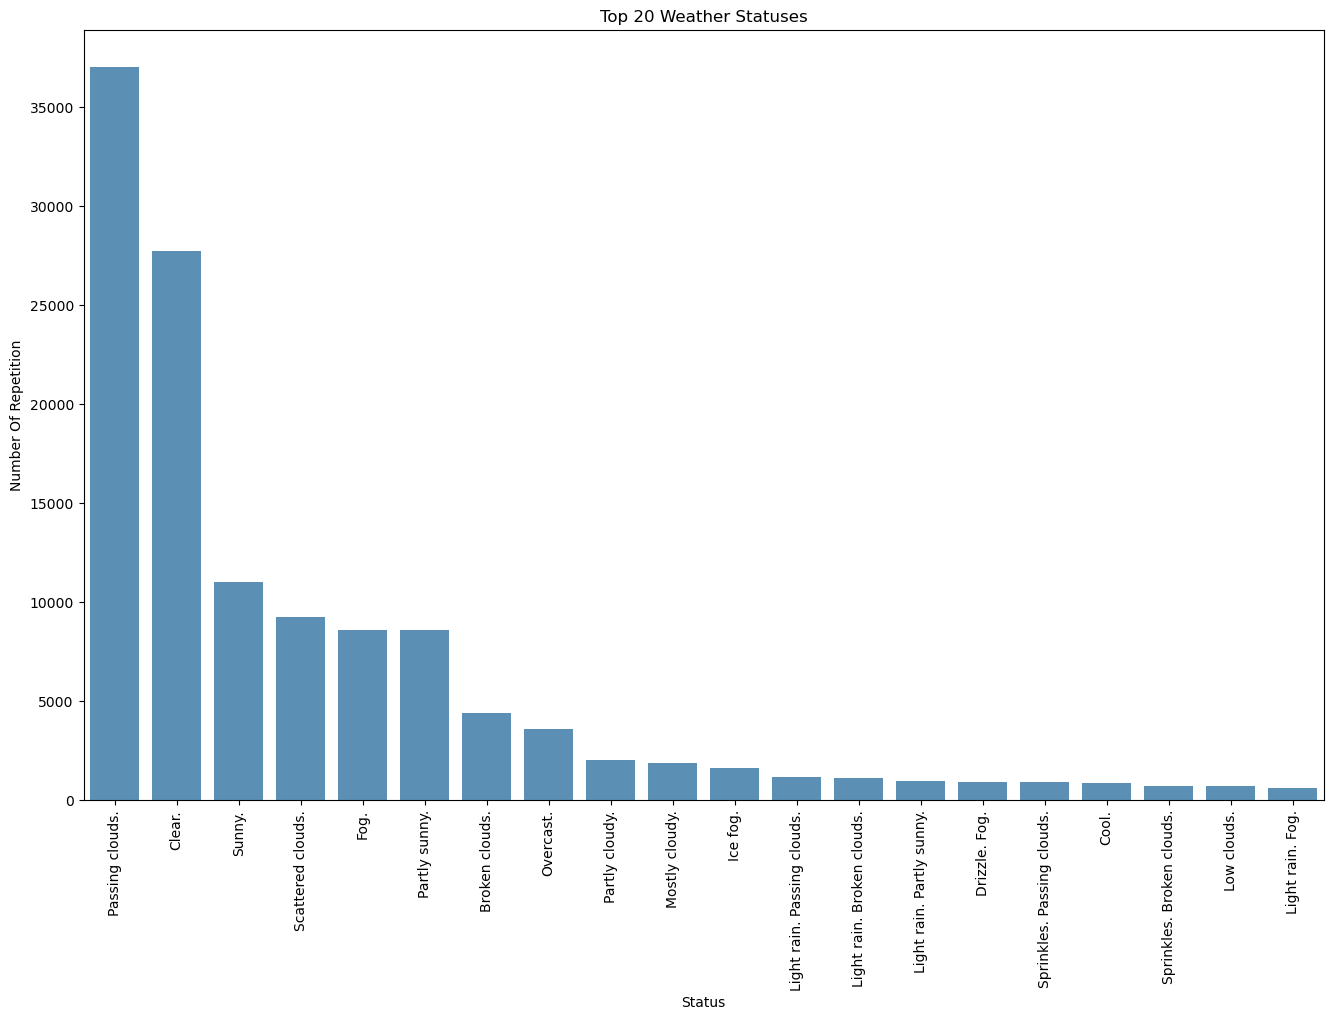

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get value counts and select top 20
weather_counts = belgium_weather.weather.value_counts().head(20)

plt.figure(figsize=(16,10))

# Plot only top 20
sns.barplot(x=weather_counts.index, y=weather_counts.values, alpha=0.8)

plt.xticks(rotation=90)
plt.title('Top 20 Weather Statuses')
plt.xlabel('Status')
plt.ylabel('Number Of Repetition')
plt.show()

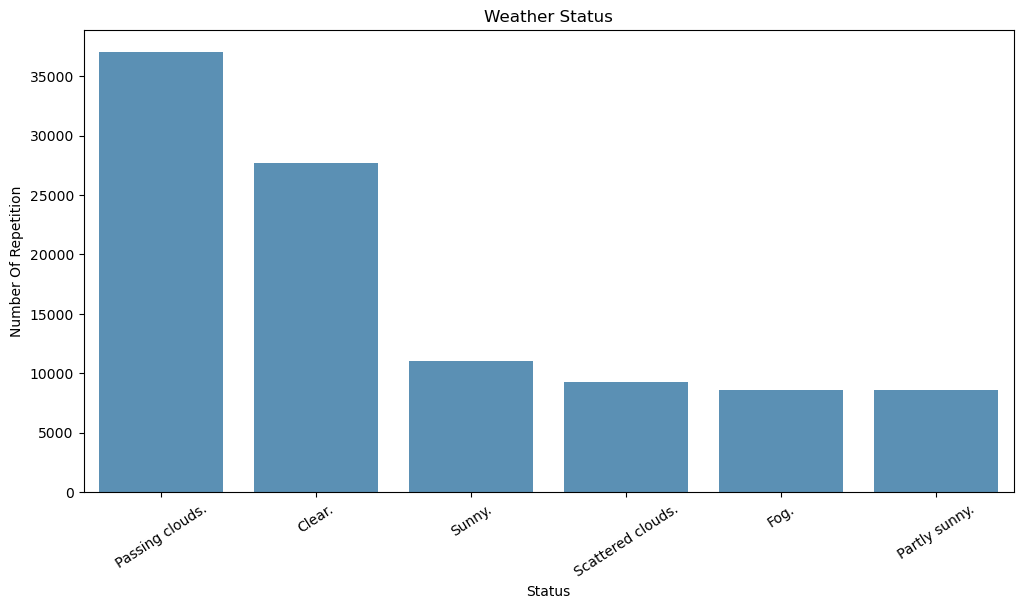

In [10]:
from matplotlib import pyplot as plt
belgium_weather.weather.value_counts()
weather_counts = belgium_weather.weather.value_counts().head(6)

plt.figure(figsize=(12,6))
sns.barplot(x=weather_counts.index, y=weather_counts.values, alpha=0.8)
plt.xticks(rotation=33)
plt.title('Weather Status')
plt.xlabel('Status')
plt.ylabel('Number Of Repetition')
plt.show()

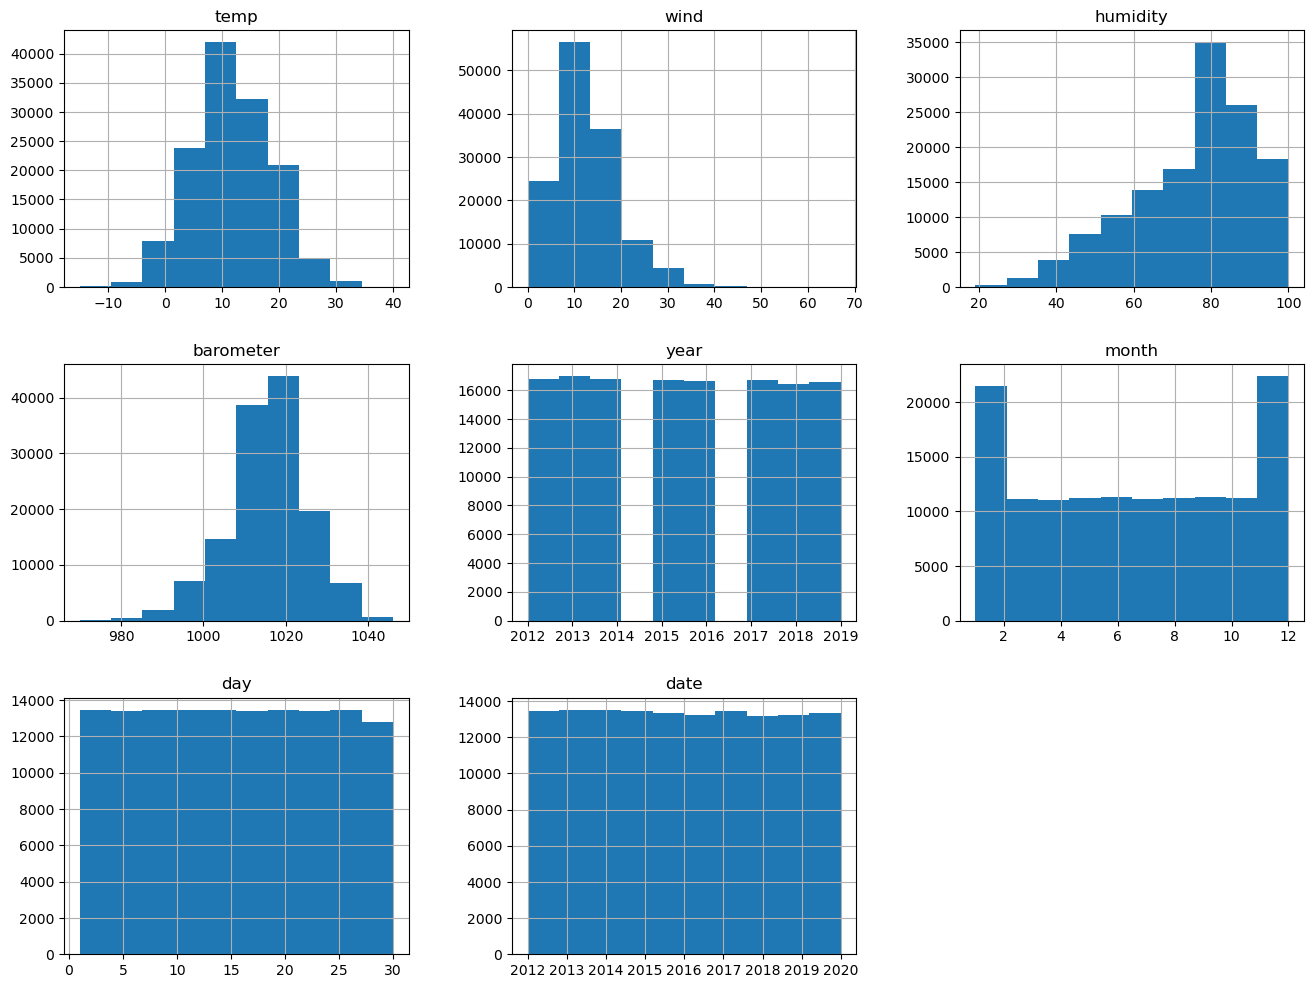

In [11]:
belgium_weather.hist(figsize=(16,12))
plt.show()

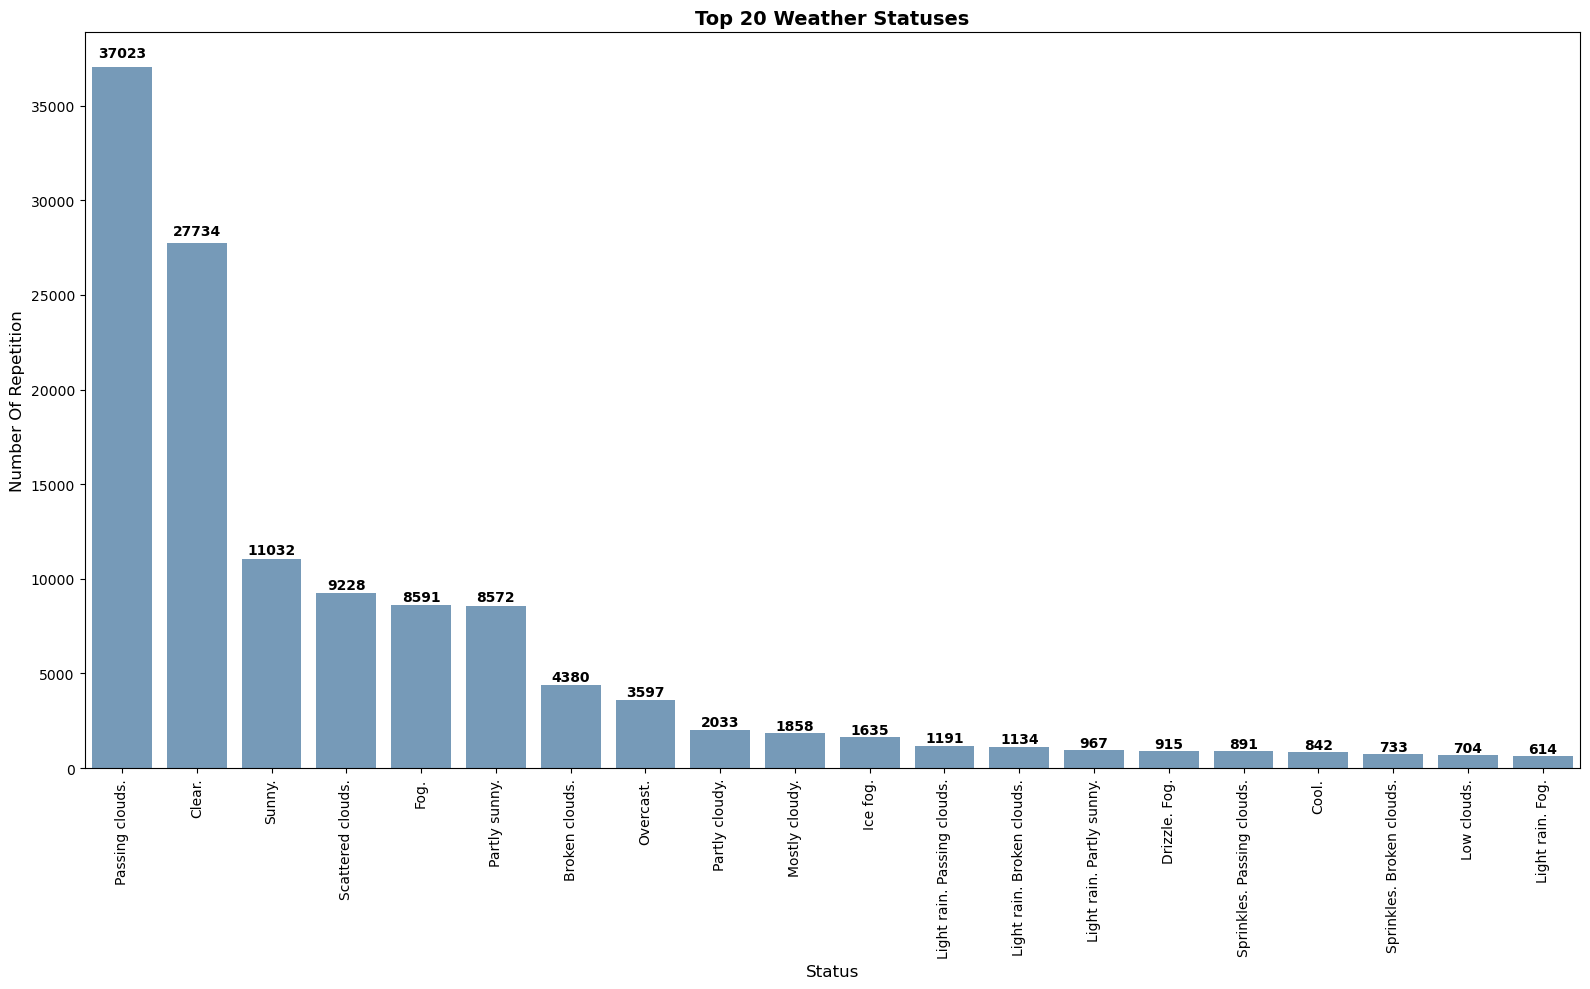

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 20
weather_counts = belgium_weather.weather.value_counts().head(20)

plt.figure(figsize=(16,10))

# Changed color - using a nice dark blue
sns.barplot(x=weather_counts.index, y=weather_counts.values, alpha=0.8, color='steelblue')

plt.xticks(rotation=90)
plt.title('Top 20 Weather Statuses', fontsize=14, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number Of Repetition', fontsize=12)

# Add bold data labels
for i, (status, count) in enumerate(weather_counts.items()):
    plt.text(i, count + (count * 0.01), str(count), 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

C:\Users\Manar\AppData\Local\Temp\ipykernel_3148\870264724.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_counts.index, y=weather_counts.values, alpha=0.9, palette=colors)


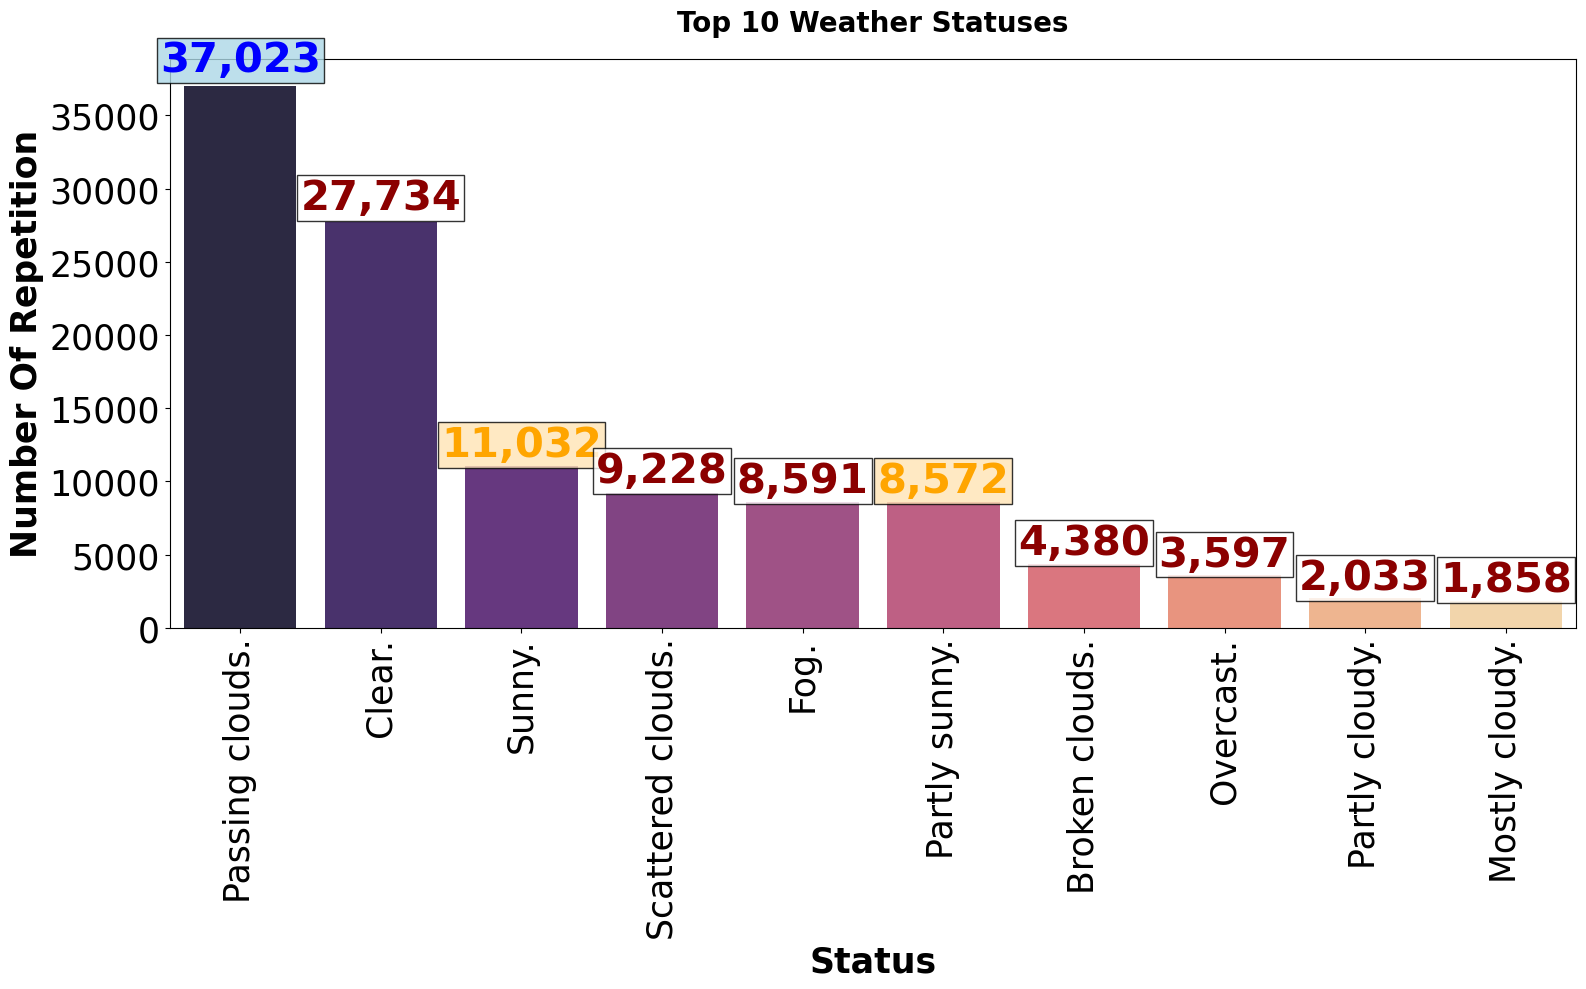

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 10
weather_counts = belgium_weather.weather.value_counts().head(10)

plt.figure(figsize=(16,10))

# Get 10 colors from magma palette
colors = sns.color_palette("magma", 10)

sns.barplot(x=weather_counts.index, y=weather_counts.values, alpha=0.9, palette=colors)

# Larger font sizes for all elements
plt.xticks(rotation=90, fontsize=25)
plt.yticks(fontsize=25)

plt.title('Top 10 Weather Statuses', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Status', fontsize=25, fontweight='bold')
plt.ylabel('Number Of Repetition', fontsize=25, fontweight='bold')

# Add data labels with conditional coloring for specific statuses
for i, (status, count) in enumerate(weather_counts.items()):
    # Check if status matches the ones we want to highlight
    status_lower = status.lower()
    
    if 'passing clouds' in status_lower:
        # Special color for passing clouds
        label_color = 'blue'
        bbox_color = 'lightblue'
    elif 'sunny' in status_lower:
        # Special color for sunny
        label_color = 'orange'
        bbox_color = '#FFE4B5'  # Light orange
    else:
        # Default color for others
        label_color = 'darkred'
        bbox_color = 'white'
    
    plt.text(i, count + (count * 0.01), f'{count:,}', 
             ha='center', va='bottom', fontsize=30, fontweight='bold',
             color=label_color, 
             bbox=dict(facecolor=bbox_color, alpha=0.8, edgecolor='black', pad=2))

plt.tight_layout()
plt.savefig("top_10_weather_statuses.png")
plt.savefig('top_10_weather_statuses.pdf', format='pdf')
plt.show()




In [ ]:
belgium_weather['date']

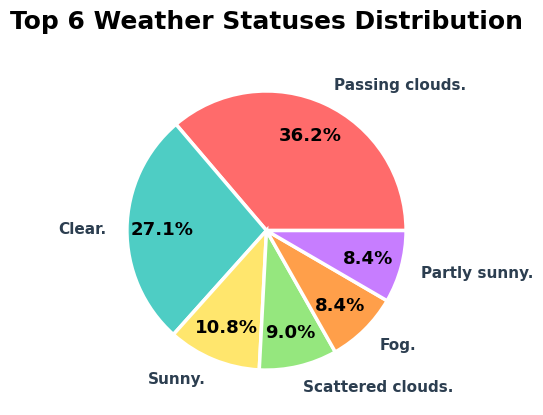

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 6
weather_counts = belgium_weather.weather.value_counts().head(6)

# Create figure
plt.figure(figsize=(5,5))

# Vibrant, bright color palette (not dark)
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E77E', '#FF9F4A', '#C77DFF']
# Alternative bright palettes:
# colors = sns.color_palette("Set2", 6)  # Soft but vibrant
# colors = sns.color_palette("pastel", 6)  # Very light
# colors = ['#FFB3BA', '#B5EAD7', '#FFDAC1', '#E2F0CB', '#B5EAD7', '#C7CEEA']

# Create pie chart
wedges, texts, autotexts = plt.pie(weather_counts.values, 
                                     labels=weather_counts.index,
                                     colors=colors,
                                     autopct='%1.1f%%',
                                     pctdistance=0.75,
                                     labeldistance=1.15,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'white', 'linewidth': 2.5})

# Make percentage labels bold and clear - NO RECTANGLES
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color('000000')
    # Removed the set_bbox line that created rectangles

# Make category labels bold
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
    text.set_color('#2C3E50')

plt.title('Top 6 Weather Statuses Distribution', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("png_format_chart.png")
plt.savefig('pdf_format_chart.pdf', format='pdf')
plt.show()


In [ ]:
belgium_weather.info()

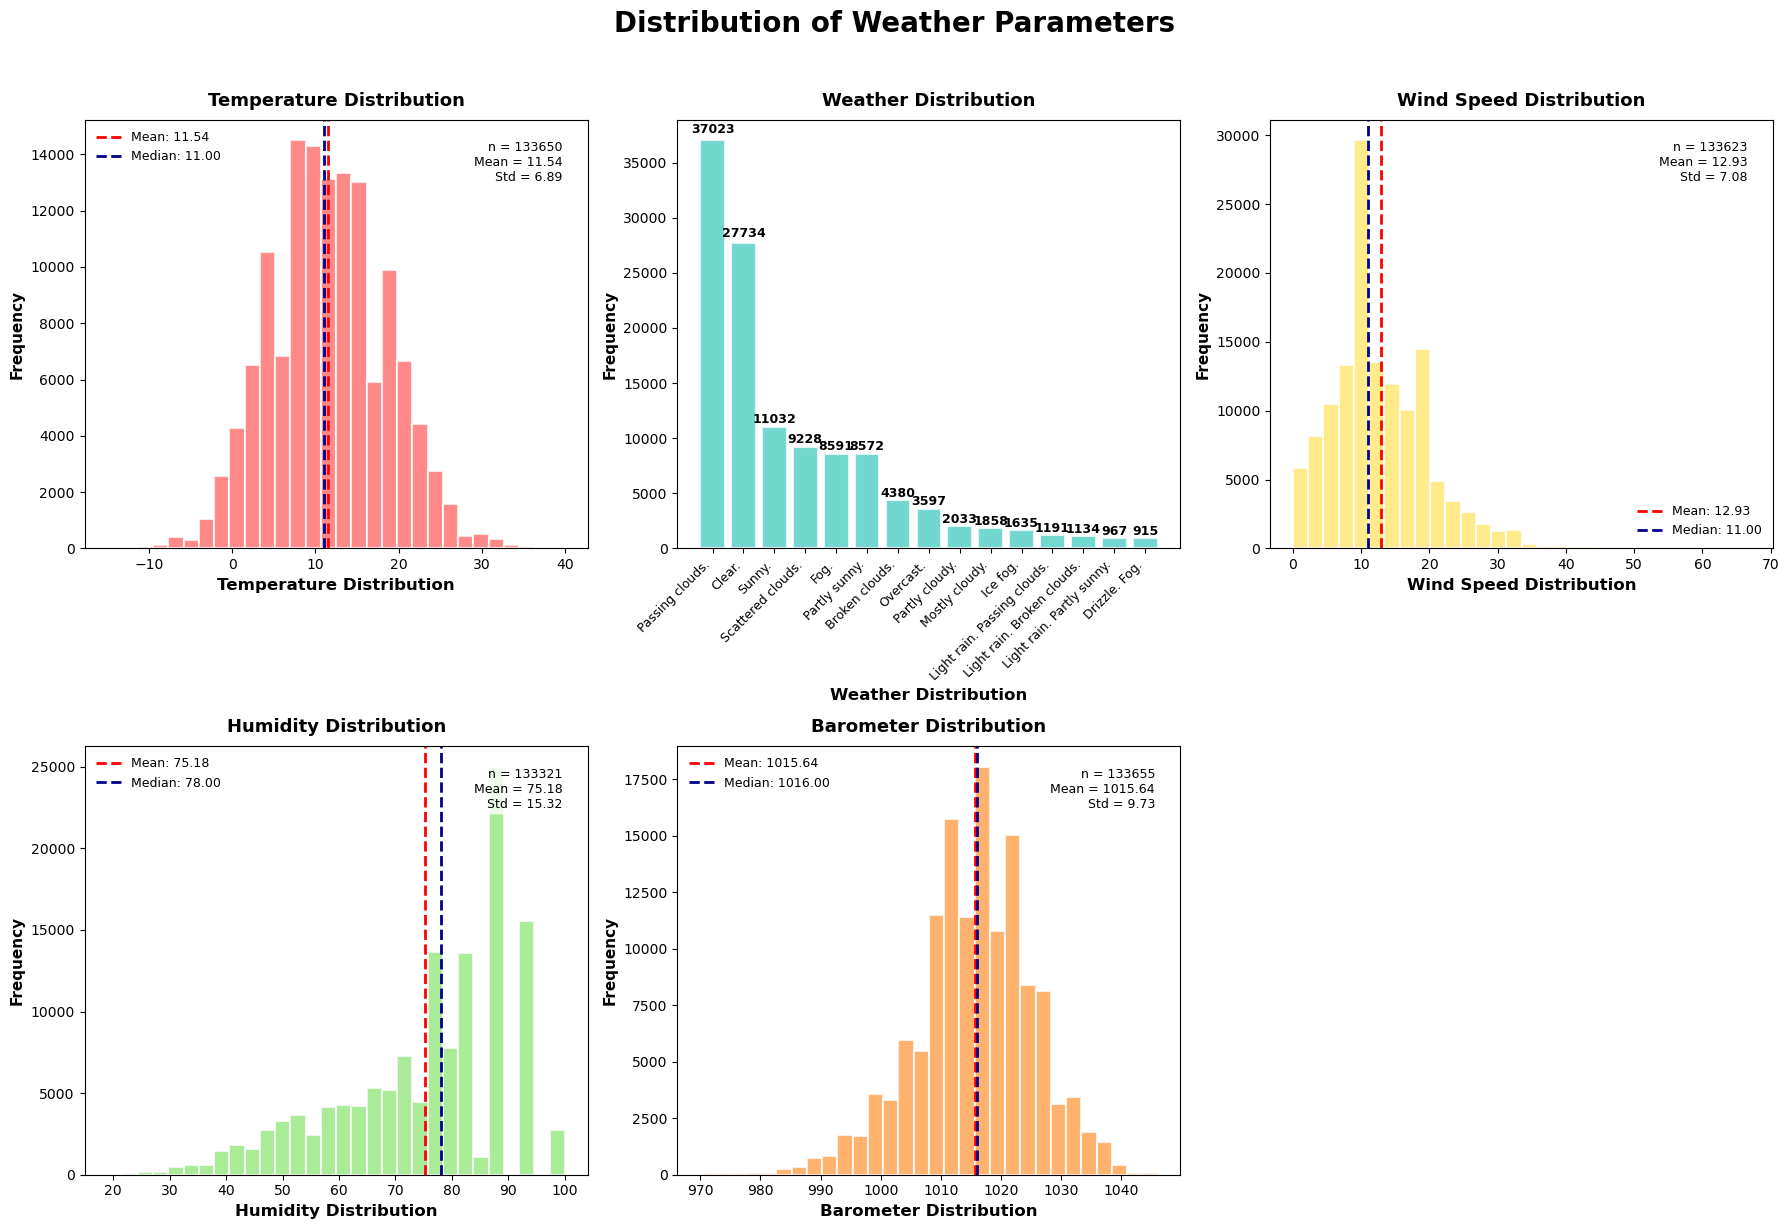

In [15]:
# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Weather Parameters', fontsize=20, fontweight='bold', y=1.02)

# Flatten axes for easy iteration
axes = axes.flatten()

# Define vibrant colors matching the pie chart
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E77E', '#FF9F4A', '#C77DFF']

# Define the columns and their titles
columns = ['temp', 'weather', 'wind', 'humidity', 'barometer']
titles = ['Temperature Distribution', 'Weather Distribution', 'Wind Speed Distribution', 
          'Humidity Distribution', 'Barometer Distribution']

# Plot histograms for each column
for i, (col, title, color) in enumerate(zip(columns, titles, colors)):
    if col == 'weather':
        # For weather (categorical), use value counts
        weather_counts = belgium_weather[col].value_counts().head(15)  # Top 15 weather types
        axes[i].bar(range(len(weather_counts)), weather_counts.values, color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
        axes[i].set_xticks(range(len(weather_counts)))
        axes[i].set_xticklabels(weather_counts.index, rotation=45, ha='right', fontsize=9)
        axes[i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        
        # Add data labels on bars
        for j, (idx, val) in enumerate(weather_counts.items()):
            axes[i].text(j, val + (val * 0.01), str(val), 
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    else:
        # For numerical columns
        axes[i].hist(belgium_weather[col].dropna(), bins=30, color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
        axes[i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        
        # Add mean and median lines
        mean_val = belgium_weather[col].mean()
        median_val = belgium_weather[col].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='darkblue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[i].legend(fontsize=9, frameon=False)
        
        # Add text box with statistics
        stats_text = f'n = {len(belgium_weather[col].dropna())}\nMean = {mean_val:.2f}\nStd = {belgium_weather[col].std():.2f}'
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes, 
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))
    
    axes[i].set_xlabel(title, fontsize=12, fontweight='bold')
    axes[i].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axes[i].grid(False)  # Remove gridlines

# Remove the empty subplot (6th one)
fig.delaxes(axes[5])
plt.savefig("distribution_of_weather_params.png")
plt.savefig('distribution_of_weather_params.pdf', format='pdf')
plt.tight_layout()
plt.show()

In [ ]:
# Create figure with adjusted spacing
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Weather Parameters Distribution Analysis', fontsize=18, fontweight='bold', y=1.02)

# Flatten axes for easy iteration
axes = axes.flatten()

# Define vibrant colors matching the pie chart
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E77E', '#FF9F4A', '#C77DFF']

# Define the columns and their titles
columns = ['temp', 'weather', 'wind', 'humidity', 'barometer']
titles = ['Temperature Distribution', 'Weather Distribution', 'Wind Speed Distribution', 
          'Humidity Distribution', 'Barometric Pressure (hPa)']  # Clearer title with units

# Plot histograms for each column
for i, (col, title, color) in enumerate(zip(columns, titles, colors)):
    if col == 'weather':
        # For weather (categorical), use value counts
        weather_counts = belgium_weather[col].value_counts().head(15)
        axes[i].bar(range(len(weather_counts)), weather_counts.values, color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
        axes[i].set_xticks(range(len(weather_counts)))
        axes[i].set_xticklabels(weather_counts.index, rotation=45, ha='right', fontsize=9)
        axes[i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        
        # Add data labels on bars
        for j, (idx, val) in enumerate(weather_counts.items()):
            axes[i].text(j, val + (val * 0.01), str(val), 
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    else:
        # For numerical columns
        n, bins, patches = axes[i].hist(belgium_weather[col].dropna(), bins=30, color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
        axes[i].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        
        # Add mean and median lines
        mean_val = belgium_weather[col].mean()
        median_val = belgium_weather[col].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='darkblue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[i].legend(fontsize=9, frameon=False)
        
        # Add text box with statistics
        stats_text = f'n = {len(belgium_weather[col].dropna())}\nMean = {mean_val:.2f}\nStd = {belgium_weather[col].std():.2f}'
        axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes, 
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))
    
    axes[i].set_xlabel(title, fontsize=12, fontweight='bold')
    axes[i].set_title(title.split('(')[0].strip(), fontsize=13, fontweight='bold', pad=10)
    axes[i].grid(False)  # Remove gridlines

# Adjust barometer chart (index 4) specifically
# Get current y-limit and set a lower top margin
current_ylim = axes[4].get_ylim()
axes[4].set_ylim(0, current_ylim[1] * 0.85)  # Reduce top by 15% to push chart lower

# Remove the empty subplot (6th one)
fig.delaxes(axes[5])

# Adjust layout to give more space and prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.95, bottom=0.08, hspace=0.32, wspace=0.28)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create isolated figure for barometer
plt.figure(figsize=(10, 6))

# Same vibrant color as before
barometer_color = '#FF9F4A'  # Same orange color from the pie chart

# Create histogram
n, bins, patches = plt.hist(belgium_weather['barometer'].dropna(), 
                            bins=30, 
                            color=barometer_color, 
                            alpha=0.8, 
                            edgecolor='white', 
                            linewidth=1.5)

# Add mean and median lines
mean_val = belgium_weather['barometer'].mean()
median_val = belgium_weather['barometer'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, label=f'Mean: {mean_val:.2f} hPa')
plt.axvline(median_val, color='darkblue', linestyle='--', linewidth=2.5, label=f'Median: {median_val:.2f} hPa')

# Add text box with statistics
stats_text = f'Count: {len(belgium_weather["barometer"].dropna()):,}\nMean: {mean_val:.2f} hPa\nMedian: {median_val:.2f} hPa\nStd: {belgium_weather["barometer"].std():.2f} hPa'
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#FF9F4A', linewidth=2))

# Customize chart
plt.xlabel('Barometric Pressure (hPa)', fontsize=13, fontweight='bold')
plt.ylabel('Frequency', fontsize=13, fontweight='bold')
plt.title('Barometric Pressure Distribution', fontsize=16, fontweight='bold', pad=15, color='#FF9F4A')
plt.grid(False)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)

# Adjust layout
plt.tight_layout()
plt.show()

## Key Finding: Belgium is good location for solar panel installment ##

In [8]:
belgium_weather.to_csv("weather_in_Antwerp_analyzed.csv",index=False)